### Analytical Evaluation of the Effective Dynamics (FAPT)

While the numerical propagation of the effective state is efficient for single pulse sequences, large parameter sweeps and pulse optimizations require a less computationally demanding approach. To achieve this, the perturbative construction can be evaluated analytically.

Instead of performing the time-evolution numerically over many small steps $\delta t$, this approach uses closed-form symbolic expressions for both the transformation matrix $W(\boldsymbol\lambda)$ and the effective Hamiltonian $H_{\mathrm{eff,ad}}$. The time evolution operator $U(t, t_i)$ over the entire pulse duration is then approximated using the **Magnus expansion** (up to second order), effectively evaluating the evolution in a single analytical step. 

The following code tests this analytical framework by substituting symbolic pulse shapes (like a Gaussian amplitude) into the analytically derived Magnus operator.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import sympy as sp
from utils import * 
from FAPT import * 
from pulse_optimization import * 
s = Simulation()
import matplotlib.pyplot as plt
rH = 2
rW = 1
use_gauss = True
pulse_name = "gauss" if use_gauss else "tanh"

def setup_paper_style():
    """Sets Matplotlib defaults for scientific publication layouts."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "text.usetex": False,
        "axes.labelsize": 11.5,
        "font.size": 11,
        "legend.fontsize": 9.0,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.titlesize": 12,
        "axes.titlesize": 11.5,
        "lines.linewidth": 1.4,
        "lines.markersize": 5.0,
    })

In [2]:
from pathlib import Path
import numpy as np
import sympy as sp
DRIVE_DIRECTORY = Path("operational_res/analytical_drive_data")

def load_analytical_drive(pulse_type, drive_directory=DRIVE_DIRECTORY):
    file_path = Path(drive_directory) / f"analytical_drive_{pulse_type}_custom.npz"

    if not file_path.exists():
        raise FileNotFoundError(f"Die Datei '{file_path}' wurde nicht gefunden.")

    with np.load(file_path, allow_pickle=False) as saved_data:
        Ar_expression = sp.sympify(saved_data["Ar_srepr"].item())
        Ai_expression = sp.sympify(saved_data["Ai_srepr"].item())
        dwd_expression = sp.sympify(saved_data["wd_srepr"].item())

    pulse_data = {
        "Ar": Ar_expression,
        "Ai": Ai_expression,
        "wd": dwd_expression,
    }
    print(f"Symbolische Pulsform geladen: '{file_path}'")
    return pulse_data

drive = load_analytical_drive(pulse_type=pulse_name)
Ar_expr = drive["Ar"]
Ai_expr = drive["Ai"]
wd_expr = drive["wd"]

def get_symbol_by_name(expressions, symbol_name):
    free_symbols = set().union(*(expression.free_symbols for expression in expressions if expression is not None))
    matching_symbols = [symbol for symbol in free_symbols if symbol.name == symbol_name]

    if not matching_symbols:
        raise KeyError(f"Das Symbol '{symbol_name}' kommt in den geladenen Ausdrücken nicht vor.")
    return matching_symbols[0]

loaded_expressions = (Ar_expr, Ai_expr, wd_expr)
t_sym = get_symbol_by_name(expressions=loaded_expressions, symbol_name="t")
amp_scale_sym = get_symbol_by_name(expressions=loaded_expressions, symbol_name="f")
tg_sym = get_symbol_by_name(expressions=loaded_expressions, symbol_name="t_g")
display(Ar_expr)
display(Ai_expr)
display(wd_expr)

Symbolische Pulsform geladen: 'operational_res/analytical_drive_data/analytical_drive_gauss_custom.npz'


1.0*(85.614672868478*f*exp(5.55555555555556*t/t_g) - 85.614672868478*f*exp(5.55555555555556*t**2/t_g**2))*exp(-5.55555555555556*t**2/t_g**2)/t_g

1.0*(810.494090737224*t*exp(5.55555555555556*t/t_g) - 405.247045368612*t_g*exp(5.55555555555556*t/t_g))*exp(-5.55555555555556*t**2/t_g**2)/t_g**3

1.0*(4.43804328641986*t_g**2*exp(16.6666666666667*t**2/t_g**2) - 67.9151348433771*exp(5.55555555555556*t/t_g)*exp(11.1111111111111*t**2/t_g**2) + 33.9575674216885*exp(11.1111111111111*t/t_g)*exp(5.55555555555556*t**2/t_g**2) + 33.9575674216885*exp(16.6666666666667*t**2/t_g**2))*exp(-16.6666666666667*t**2/t_g**2)/t_g**2

In [3]:
def replace_loaded_symbols(expression, t_sym, amp_scale_sym, tg_sym):
    symbol_map = {}

    for symbol in expression.free_symbols:
        if symbol.name == "t":
            symbol_map[symbol] = t_sym
        elif symbol.name in ("tg", "t_g", r"t_{g}"):
            symbol_map[symbol] = tg_sym
        elif symbol.name == "f":
            symbol_map[symbol] = amp_scale_sym
    return expression.xreplace(symbol_map)


def make_analytical_pulse_builder(Ar_expr, Ai_expr, wd_expr):
    def pulse_shape_builder(t_sym, p_syms):
        tg_sym, wd_offset_sym, amp_scale_sym = p_syms

        Ar = replace_loaded_symbols(expression=Ar_expr, t_sym=t_sym, amp_scale_sym=amp_scale_sym, tg_sym=tg_sym)
        Ai = replace_loaded_symbols(expression=Ai_expr, t_sym=t_sym, amp_scale_sym=amp_scale_sym, tg_sym=tg_sym)
        wd = replace_loaded_symbols(expression=wd_expr, t_sym=t_sym, amp_scale_sym=amp_scale_sym, tg_sym=tg_sym)

        A = (Ar + sy.I * Ai)
        wd =  wd + wd_offset_sym

        return A, wd

    return pulse_shape_builder

In [4]:
pulse_builder = make_analytical_pulse_builder(Ar_expr=Ar_expr, Ai_expr=Ai_expr, wd_expr=wd_expr)

base_parameter_names = [
    "t_g",
    "wd_offset",
    "amp_scale",
]

param_names = ["wd_offset", "amp_scale"]

def create_binder(include_geometric = False, include_micromotion = False, include_g_correction=False, verbose=False, param_names=param_names):
    H_gauss_base, M_gauss_base, M_inv_0_gauss_base = prepare_floquet_functions(pulse_shape_builder=pulse_builder, p_names=base_parameter_names, s=s, rH=rH, rW=rW, include_geometric=include_geometric, include_micromotion=include_micromotion, include_g_correction=include_g_correction, verbose=verbose)
    def bind_func(tg_target, H_base=H_gauss_base, M_base=M_gauss_base, M_inv_0_base=M_inv_0_gauss_base):
        def absolute_parameters(offsets):
            # Falls offsets als einzelnes Container-Objekt (Tupel/Liste/Array) übergeben wurde, entpacken
            if len(offsets) == 1 and isinstance(offsets[0], (tuple, list, np.ndarray)):
                offsets = offsets[0]
                
            values = dict(zip(param_names, offsets))
            return values["wd_offset"], values["amp_scale"]

        def H_func(t, *offsets):
            wd_offset, amp_scale = absolute_parameters(offsets)
            return H_base(t, tg_target, wd_offset, amp_scale)

        def M_func(t, *offsets):
            wd_offset, amp_scale = absolute_parameters(offsets)
            return M_base(t, tg_target, wd_offset, amp_scale)

        def M_inv_0_func(*offsets):
            wd_offset, amp_scale = absolute_parameters(offsets)
            return M_inv_0_base(tg_target, wd_offset, amp_scale)

        H_func.is_time_dependent = getattr(H_base, "is_time_dependent", True)
        return H_func, M_func, M_inv_0_func
    return bind_func
bind_floquet_functions = create_binder()

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg as scipy_linalg
import sympy as sy
from tqdm import tqdm

tg_list = np.linspace(50.0, 700.0, 30)
param_ranges = {"wd_offset": (-0.005, 0.05), "amp_scale": (0.8, 1.4)}
s = Simulation()


def for_tg(
    tg, binder, debug=False, verbose=False, low=False, plot_dynamics=False
):

    def sim_pulse(tg, amp, off):
        Ar = sy.lambdify(
            t_sym,
            replace_loaded_symbols(Ar_expr, t_sym, amp, tg),
            "numpy",
        )
        Ai = sy.lambdify(
            t_sym,
            replace_loaded_symbols(Ai_expr, t_sym, amp, tg),
            "numpy",
        )
        wd = sy.lambdify(
            t_sym,
            replace_loaded_symbols(wd_expr, t_sym, amp, tg) + off,
            "numpy",
        )

        q = lambda t, args=None: Ar(t) * np.cos(wd(t) * t) + Ai(t) * np.sin(
            wd(t) * t
        )
        tlist = np.linspace(0.0, tg, max(101, int(tg * 8)))

        columns = []
        result_a = None

        for initial_state in s.comp_indices:
            result = sesolve([s.H0, [s.V1, q]], s.E_states[initial_state], tlist)

            if initial_state == s.state_a:
                result_a = result

            columns.append([
                state.overlap(result.states[-1])
                for state in s.E_states[s.comp_indices]
            ])

        U = np.column_stack(columns)
        return infid_population(U), q, tlist, result_a

    H_f, M_f, M_i0_f = binder(tg)
    popsize, maxiter, tol = (8, 40, 1e-5) if low else (17, 80, 1e-8)

    p_opt, f_inf = optimize_pulse_parameters(
        H_f,
        M_f,
        M_i0_f,
        param_ranges,
        s,
        tg,
        popsize=popsize,
        maxiter=maxiter,
        tol=tol,
        verbose=verbose,
    )

    infid_direct, _, tlist, result_a = sim_pulse(
        tg, p_opt["amp_scale"], p_opt["wd_offset"]
    )

    if plot_dynamics:
        states = [s.state_a, s.state_b, s.state_c]
        pops_direct = np.array([
            [abs(s.E_states[state].overlap(psi)) ** 2 for psi in result_a.states]
            for state in states
        ])

        # Floquet-Dynamik aus |a>
        p_vals = (p_opt["wd_offset"], p_opt["amp_scale"])
        t_mids = 0.5 * (tlist[:-1] + tlist[1:])
        dt = tlist[1] - tlist[0]

        if hasattr(H_f, "evaluate_stack"):
            H_all = H_f.evaluate_stack(t_mids, *p_vals)
        elif getattr(H_f, "is_time_dependent", True):
            H_all = np.stack(
                [
                    np.asarray(H_f(t, *p_vals), dtype=complex).reshape(
                        s.d_res, s.d_res
                    )
                    for t in t_mids
                ],
                axis=2,
            )
        else:
            H_static = np.asarray(
                H_f(t_mids[0], *p_vals), dtype=complex
            ).reshape(s.d_res, s.d_res)

            H_all = np.repeat(H_static[:, :, np.newaxis], len(t_mids), axis=2)

        M_inv_0 = np.asarray(M_i0_f(*p_vals), dtype=complex).reshape(
            s.d_res, s.D
        )

        phi_a = M_inv_0[:, s.state_a]
        U_eff = np.eye(s.d_res, dtype=complex)
        pops_floquet = np.zeros((2, len(tlist)))

        for k, time in enumerate(tlist):
            M = np.asarray(M_f(time, *p_vals), dtype=complex).reshape(
                s.D, s.d_res
            )

            psi_floquet = M @ U_eff @ phi_a
            norm = np.linalg.norm(psi_floquet)

            if norm < 1e-14:
                raise ValueError(
                    f"Floquet state has vanishing norm at t={time}."
                )

            psi_floquet /= norm
            pops_floquet[:, k] = np.abs(psi_floquet[[s.state_a, s.state_b]]) ** 2

            if k < len(t_mids):
                U_eff = (
                    scipy_linalg.expm(-1j * H_all[:, :, k] * dt) @ U_eff
                )

        # Plot Setup
        setup_paper_style()

        # Exakt aus dem Screenshot extrahierte Farben
        c_a = "#1f77b4"  # Kräftiges Blau (a-State)
        c_b = "#ff7f0e"  # Kräftiges Rot (b-State)
        c_leak = "#6CB86C"  # Mattes Grün (c-State / Leakage)
        c_infid = "#8A71B5"  # Mattes Lila (Infidelity / Zusatz)
        c_theory = "#000000"  # Schwarz (FPT-Theorie)

        plot_style = {
            "axes.labelsize": 13.5,
            "axes.titlesize": 13.0,
            "xtick.labelsize": 11.5,
            "ytick.labelsize": 11.5,
            "legend.fontsize": 10.5,
            "lines.linewidth": 2.0,
        }

        with plt.rc_context(plot_style):
            x = tlist / tg
            leakage_direct = np.ma.masked_less_equal(pops_direct[2], 0.0)

            fig, ax = plt.subplots(figsize=(7.2, 4.0), constrained_layout=True)
            ax_log = ax.twinx()
            ax_log.set_yscale("log")

            # Direkte Populationsdynamik
            ax.plot(
                x,
                pops_direct[0],
                "-",
                color=c_a,
                lw=2.0,
                label=r"Direct $|\langle\psi(t)|a\rangle|^2$",
            )
            ax.plot(
                x,
                pops_direct[1],
                "-",
                color=c_b,
                lw=2.0,
                label=r"Direct $|\langle\psi(t)|b\rangle|^2$",
            )

            # FPT-Populationsdynamik
            ax.plot(
                x,
                pops_floquet[0],
                "--",
                color=c_theory,
                lw=1.8,
                zorder=5,
                label=r"FPT $|\langle\psi(t)|a\rangle|^2$",
            )
            ax.plot(
                x,
                pops_floquet[1],
                ":",
                color=c_theory,
                lw=2.2,
                zorder=5,
                label=r"FPT $|\langle\psi(t)|b\rangle|^2$",
            )

            # Direkte Leakage-Population (Mattes Grün)
            ax_log.plot(
                x,
                leakage_direct,
                "-",
                color=c_leak,
                lw=2.0,
                label=r"Direct $|\langle\psi(t)|c\rangle|^2$",
            )

            # Horizontale Infidelity-Linien (Mattes Lila)
            ax_log.axhline(
                max(float(infid_direct), 1e-16),
                color=c_infid,
                linestyle="-",
                lw=1.6,
                alpha=0.90,
                label=r"Direct $I_{\mathrm{pop}}$",
            )
            ax_log.axhline(
                max(float(f_inf), 1e-16),
                color=c_infid,
                linestyle="--",
                lw=1.8,
                alpha=0.60,
                label=r"FPT $I_{\mathrm{pop}}$",
            )

            ax.set_title(
                rf"Initial state $|\psi(0)\rangle=|a\rangle$, $t_g={tg:g}\,\mathrm{{ns}}$",
                fontweight="bold",
            )
            ax.set_xlabel(r"$t/t_g$")
            ax.set_ylabel(r"Population $P_i(t)=|\langle\psi(t)|i\rangle|^2$")
            ax_log.set_ylabel(r"Leakage $P_c(t)$ and infidelity $I_{\mathrm{pop}}$")

            # X/Y Limits (Log-Skala genau bis 1e-8)
            ax.set_xlim(0.0, 1.0)
            ax.set_ylim(-0.02, 1.02)
            ax_log.set_ylim(1e-8, 1.2)

            ax.grid(True, which="both", linestyle=":", alpha=0.5, linewidth=0.8)
            ax.tick_params(direction="in")
            ax_log.tick_params(direction="in")

            population_handles, population_labels = ax.get_legend_handles_labels()
            log_handles, log_labels = ax_log.get_legend_handles_labels()
            fig.legend(
                population_handles + log_handles,
                population_labels + log_labels,
                loc="lower center",
                bbox_to_anchor=(0.5, 1.01),
                ncol=4,
                frameon=False,
            )

            output_file = Path(
                f"Figure/3/leakage_dynamics_{tg:g}ns.pdf"
            )
            output_file.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(output_file, dpi=600, bbox_inches="tight")

            plt.show()

    if debug:
        print("infid_direct:", infid_direct, "f_inf:", f_inf, "p_opt:", p_opt)

    return infid_direct, f_inf, p_opt


def run_tg_sweep(save_name, binder, debug=False, verbose=False, low=False):
    linfid_pop_direct, linfid_pop_floq, linfid_unopt_direct, linfid_unopt_floq = (
        [],
        [],
        [],
        [],
    )
    for tg in tqdm(tg_list):
        infid_direct, f_inf, _ = for_tg(
            tg, binder, debug=debug, verbose=verbose, low=low
        )
        linfid_pop_direct.append(infid_direct)
        linfid_pop_floq.append(f_inf)
    Path("operational_res/drag_popfids").mkdir(parents=True, exist_ok=True)
    np.savez(
        f"operational_res/drag_popfids/drag_popfids_data_{save_name}_{pulse_name}.npz",
        tg_list=tg_list,
        direct=linfid_pop_direct,
        floq=linfid_pop_floq,
        unopt_direct=linfid_unopt_direct,
        unopt_floq=linfid_unopt_floq,
    )

Determine optimal parameters for $t_g=150$~ns

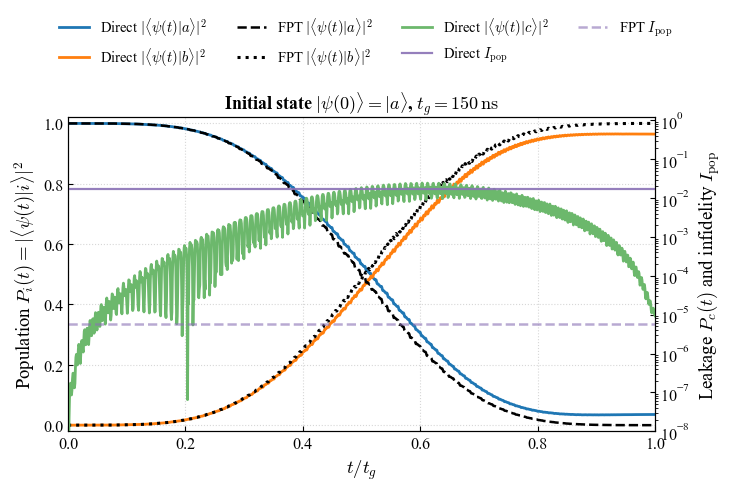

floquet:  5.62682319404928e-06  direct:  0.01770973437760548  p_opt:  {'wd_offset': np.float64(0.013655309694400153), 'amp_scale': np.float64(1.1145980114541612)}


In [6]:
inf_direct, inf_floquet, p_opt = for_tg(150, bind_floquet_functions, plot_dynamics = True, low=True)
print("floquet: ", inf_floquet, " direct: ", inf_direct, " p_opt: ", p_opt)

compute for FPT prediction

In [7]:
run_tg_sweep("custom", bind_floquet_functions, debug=False, verbose=False, low=False)

  7%|▋         | 2/30 [00:53<12:29, 26.76s/it]


KeyboardInterrupt: 

define plotting methods

In [ ]:
def load_and_plot(save_name):
    # Daten laden
    ref_data = np.load("operational_res/cos_popfids_data.npz")
    ref_tg_list, ref_infid_pop = ref_data["tg_list"], ref_data["infid_pop_list"]

    drag_data = np.load(f"operational_res/drag_popfids/drag_popfids_data_{save_name}.npz")
    tg_list = drag_data["tg_list"]
    linfid_pop_direct = drag_data["direct"]
    linfid_pop_floq = drag_data["floq"]

    def plot_infidelity_vs_tg_fullwidth(
        tg_list, 
        linfid_pop_direct, 
        linfid_pop_floq, 
        ref_tg_list=None, 
        ref_infid_pop=None, 
        title_suffix="",
        save_path=None, 
        show=True
    ):
        setup_paper_style()

        # Pulstyp dynamisch aus save_name bestimmen
        is_tanh = "tanh" in save_name.lower()
        pulse_label = "tanh" if is_tanh else "Gaussian"

        # Dynamisches Farbschema: Blau/Rot für Gauss, Violett/Grün für Tanh
        if is_tanh:
            c_direct, c_floq, c_ref = "#7b2cbf", "#2b9348", "#555555"  # Violett & Dunkelgrün
        else:
            c_direct, c_floq, c_ref = "#1f77b4", "#d62728", "#555555"  # Blau & Rot

        fullwidth_style = {
            "axes.labelsize": 12.0, "axes.titlesize": 12.5,
            "xtick.labelsize": 10.5, "ytick.labelsize": 10.5,
            "legend.fontsize": 9.5, "lines.linewidth": 1.8, "lines.markersize": 5.5,
        }

        with plt.rc_context(fullwidth_style):
            fig, ax = plt.subplots(figsize=(6.8, 3.8), dpi=300)

            # 1. Cosine Reference
            if ref_tg_list is not None and ref_infid_pop is not None:
                ax.semilogy(
                    ref_tg_list, ref_infid_pop, ":", color=c_ref, marker="^", 
                    mfc="white", mec=c_ref, mew=1.2, lw=1.5, label=r"Cosine Reference ($I_{\mathrm{pop}}$)"
                )
            # 2. Optimierte Kurven mit Pulstyp-Kennzeichnung
            ax.semilogy(
                tg_list, linfid_pop_direct, "-", color=c_direct, marker="o", 
                mfc="white", mec=c_direct, mew=1.5, label=rf"DRAG Direct ({pulse_label})"
            )
            ax.semilogy(
                tg_list, linfid_pop_floq, "--", color=c_floq, marker="s", 
                mfc="white", mec=c_floq, mew=1.5, label=rf"DRAG Floquet ({pulse_label})"
            )

            ax.set_xlabel(r"Gate duration $t_g$ [ns]")
            ax.set_ylabel(r"Population Infidelity $I_{\mathrm{pop}}$")
            ax.set_title(rf"{pulse_label} Pulse: Population Infidelity vs. $t_g${title_suffix}", fontweight="bold")
            ax.grid(True, which="both", linestyle=":", alpha=0.5, linewidth=0.8)
            ax.legend(loc="best", frameon=True, fancybox=False, edgecolor="gray", framealpha=0.9)

            fig.tight_layout()
            if save_path:
                out = Path(save_path)
                out.parent.mkdir(parents=True, exist_ok=True)
                fig.savefig(out, bbox_inches="tight")
            if show:
                plt.show()

            return fig, ax
    save_path = f"Figure/drag_results/{save_name}.pdf"
    save_path = None
    # Plot 1: Standard (nur optimierte DRAG-Daten)
    fig1, ax1 = plot_infidelity_vs_tg_fullwidth(
        tg_list, linfid_pop_direct, linfid_pop_floq,
        ref_tg_list=ref_tg_list, ref_infid_pop=ref_infid_pop,
        save_path=save_path
    )

    return fig1, ax1

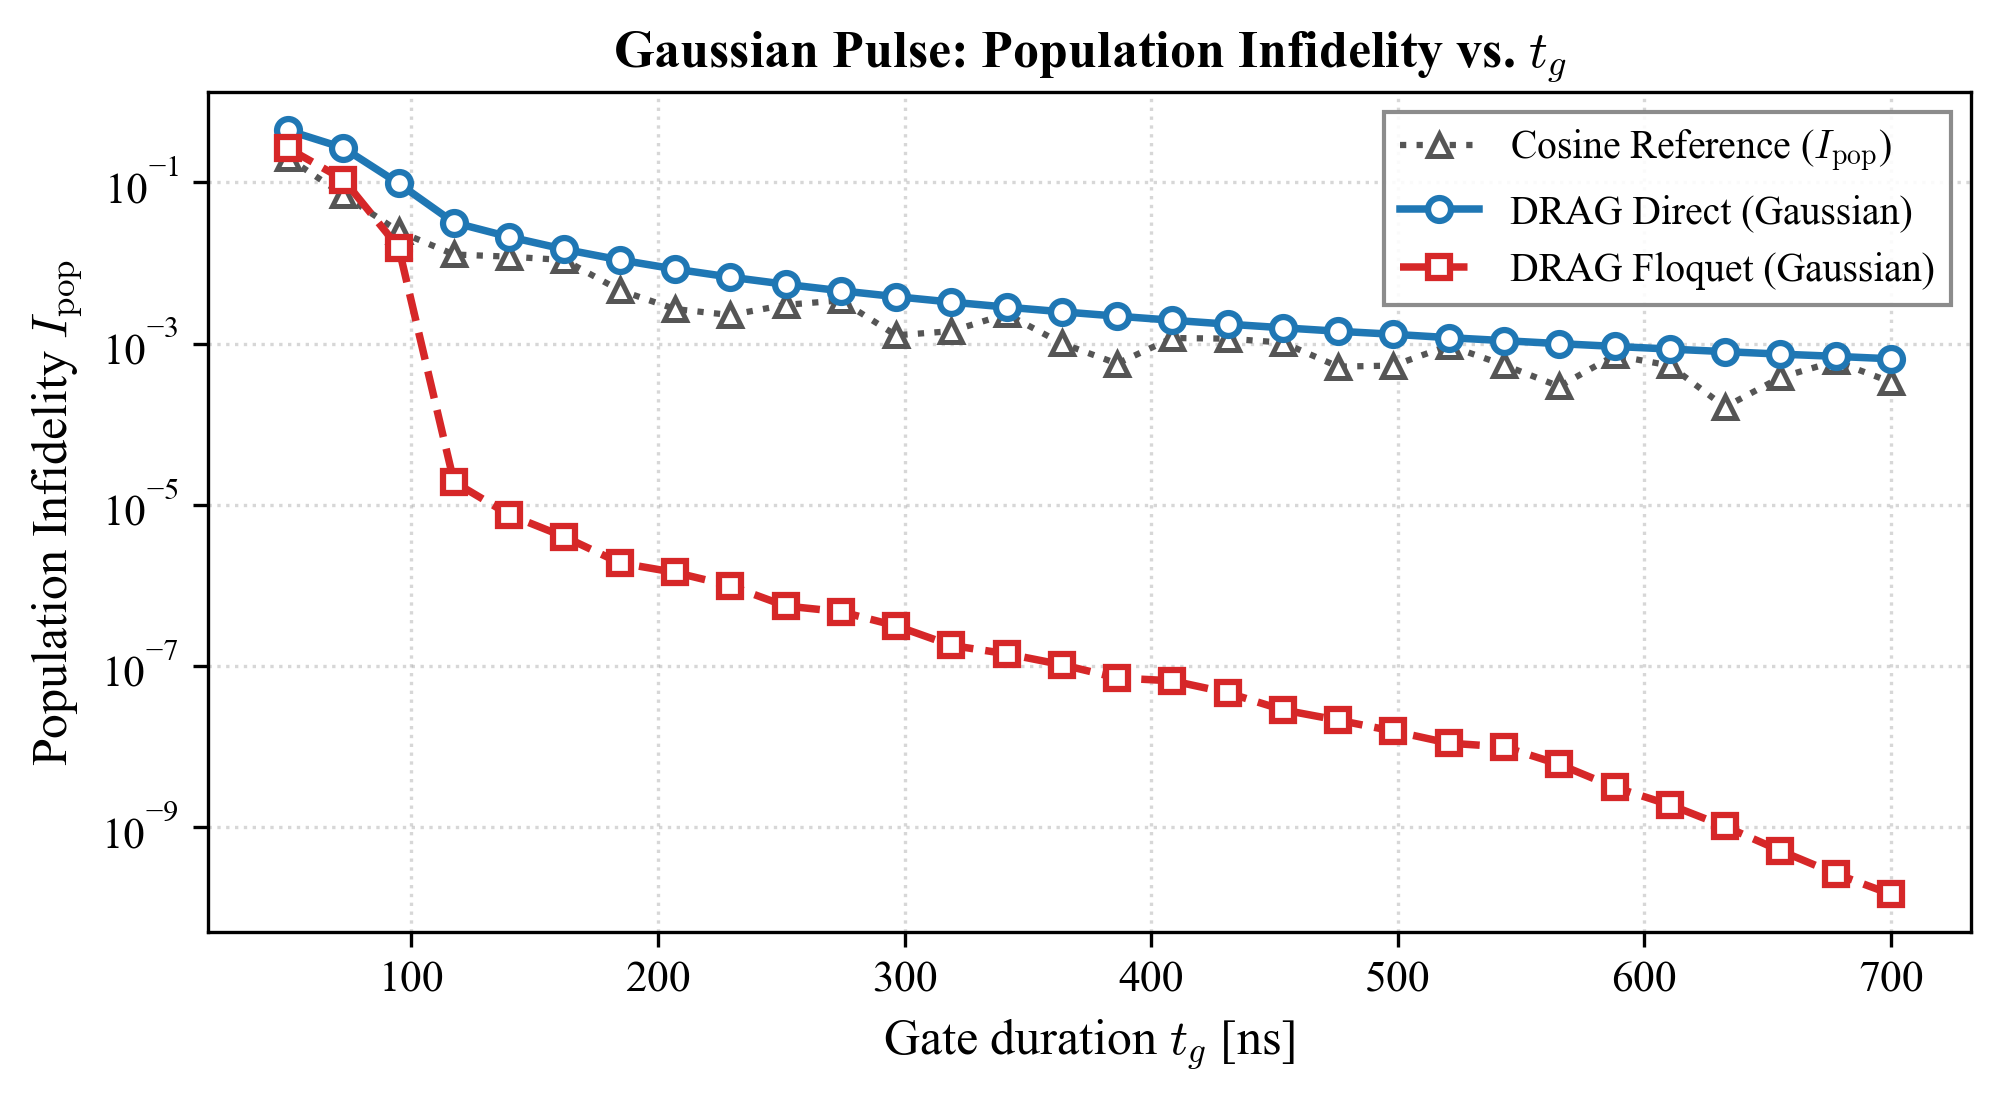

(<Figure size 2040x1140 with 1 Axes>,
 <Axes: title={'center': 'Gaussian Pulse: Population Infidelity vs. $t_g$'}, xlabel='Gate duration $t_g$ [ns]', ylabel='Population Infidelity $I_{\\mathrm{pop}}$'>)

In [ ]:
load_and_plot(f"custom_{pulse_name}")

In [ ]:
binder = create_binder(include_micromotion=True)
run_tg_sweep("custom_FAPT", binder=binder, debug=False)

100%|██████████| 30/30 [26:08<00:00, 52.27s/it]


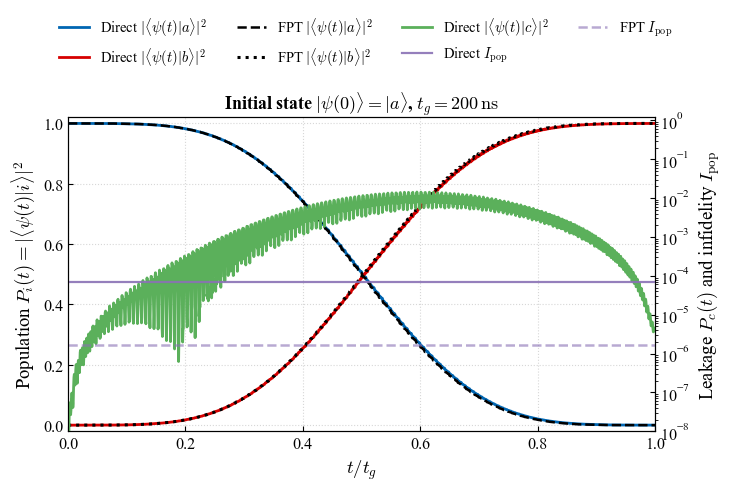

floquet:  1.6113634009329303e-06  direct:  6.84901335230581e-05  p_opt:  {'wd_offset': np.float64(0.010609068805102184), 'amp_scale': np.float64(1.1040648597664378)}


In [ ]:
inf_direct, inf_floquet, p_opt = for_tg(200, binder, plot_dynamics = True, low=True)
print("floquet: ", inf_floquet, " direct: ", inf_direct, " p_opt: ", p_opt)

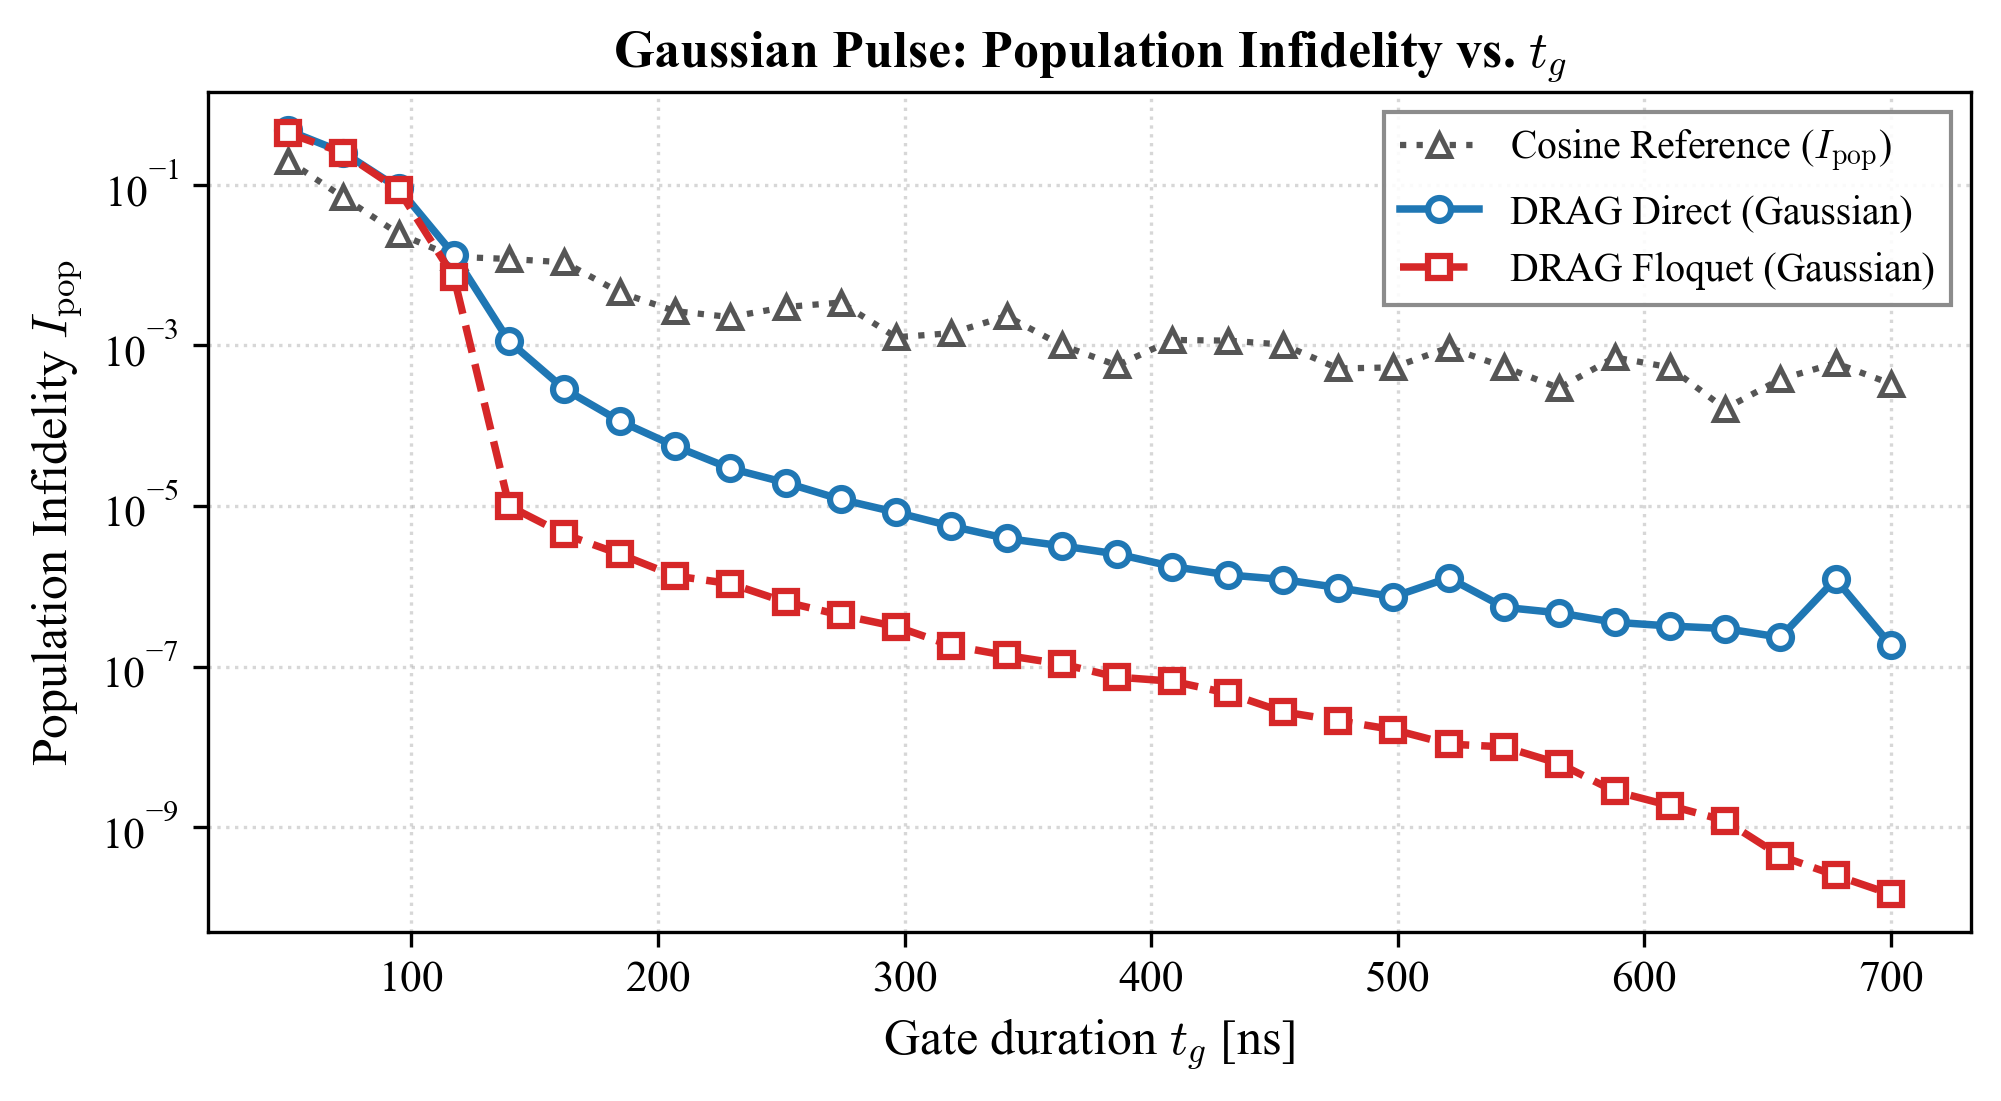

(<Figure size 2040x1140 with 1 Axes>,
 <Axes: title={'center': 'Gaussian Pulse: Population Infidelity vs. $t_g$'}, xlabel='Gate duration $t_g$ [ns]', ylabel='Population Infidelity $I_{\\mathrm{pop}}$'>)

In [ ]:
load_and_plot(f"custom_FAPT_{pulse_name}")

Check the actual dynamics to argument for FAPT use

popt:  {'wd_offset': np.float64(0.04999999510940167), 'amp_scale': np.float64(1.3880061522680234)}  infid:  0.0059938553793289495


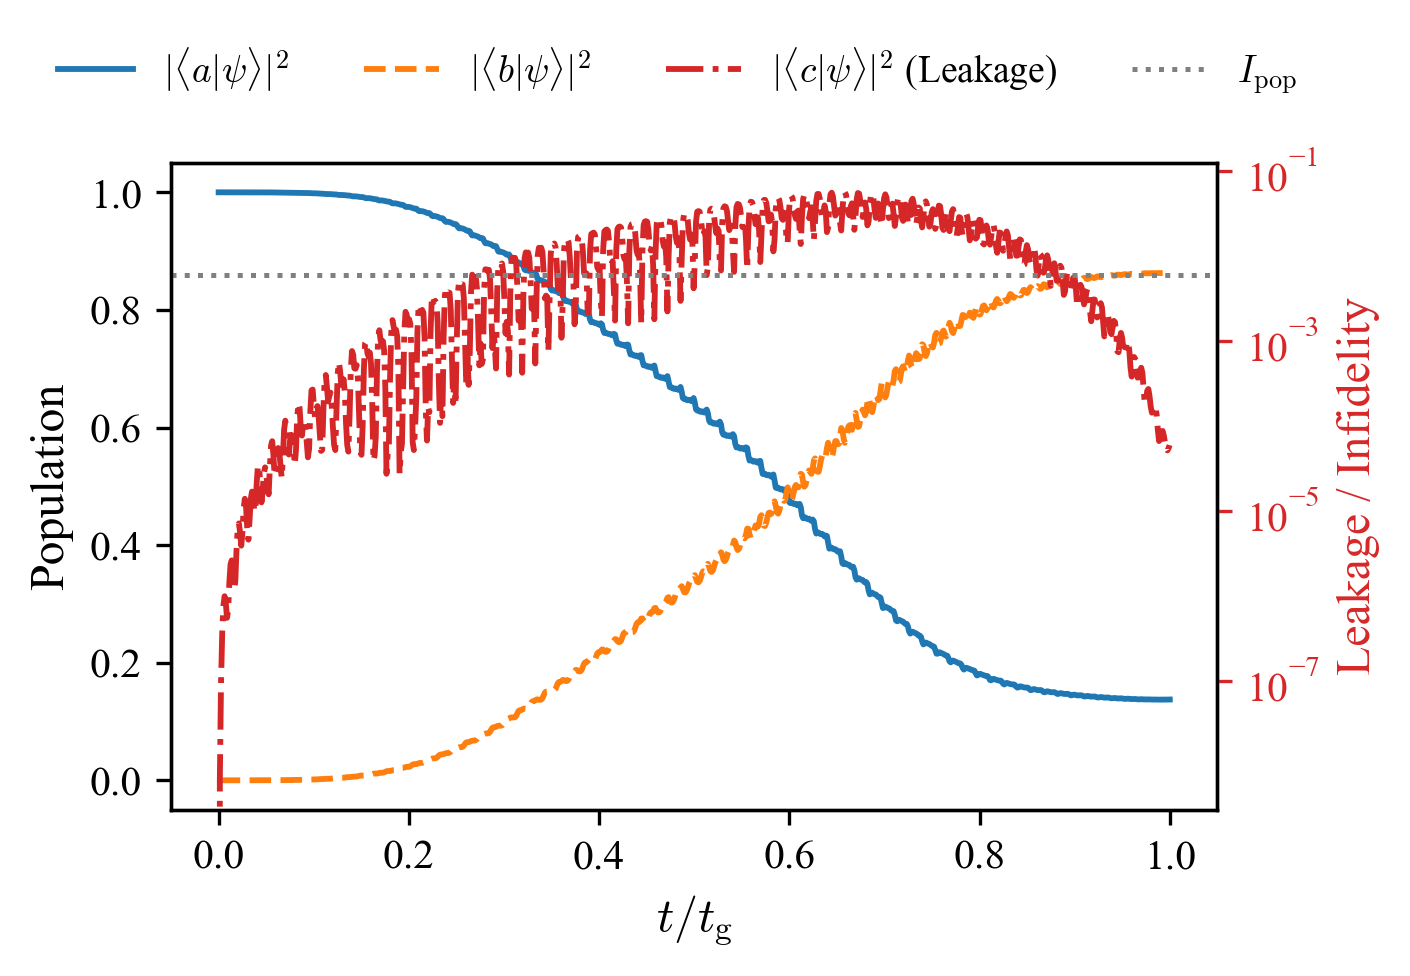

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import sesolve

# 1. Parameter & Signal für tg
tg = 100.0
H_f, M_f, M_i0_f = bind_floquet_functions(tg)
p_opt, infid = optimize_pulse_parameters(H_f, M_f, M_i0_f, param_ranges, s, tg, tol=1e-6, popsize=8, x0=np.array([0, 1]), verbose=False)
print("popt: ", p_opt, " infid: ", infid)

Ar = sy.lambdify(t_sym, replace_loaded_symbols(Ar_expr, t_sym, p_opt["amp_scale"], tg), "numpy")
Ai = sy.lambdify(t_sym, replace_loaded_symbols(Ai_expr, t_sym, p_opt["amp_scale"], tg), "numpy")
wd = sy.lambdify(t_sym, replace_loaded_symbols(wd_expr, t_sym, p_opt["amp_scale"], tg) + p_opt["wd_offset"], "numpy")
q = lambda t, a=None: Ar(t)*np.cos(wd(t)*t) + Ai(t)*np.sin(wd(t)*t)

# 2. Dynamics
tlist = np.linspace(0, tg, max(101, int(tg*8)))
res = sesolve([s.H0, [s.V1, q]], s.E_states[s.state_a], tlist)

pop_a = [np.abs(s.E_states[s.state_a].overlap(st))**2 for st in res.states]
pop_b = [np.abs(s.E_states[s.state_b].overlap(st))**2 for st in res.states]
pop_c = [np.abs(s.E_states[s.state_c].overlap(st))**2 for st in res.states]
pop_c[0]=0
# 3. Plot
fig, ax1 = plt.subplots(figsize=(4.5, 2.8), dpi=300)
ax2 = ax1.twinx()

l1, = ax1.plot(tlist/tg, pop_a, "#1f77b4", label=r"$|\langle a|\psi\rangle|^2$")
l2, = ax1.plot(tlist/tg, pop_b, "#ff7f0e", ls="--", label=r"$|\langle b|\psi\rangle|^2$")
l3, = ax2.semilogy(tlist/tg, pop_c, "#d62728", ls="-.", label=r"$|\langle c|\psi\rangle|^2$ (Leakage)")

# Horizontale Linie für die Infidelity auf der rechten Y-Achse
l4 = ax2.axhline(infid, color="gray", ls=":", lw=1.2, label=r"$I_{\mathrm{pop}}$")

ax1.set_xlabel(r"$t/t_{\mathrm{g}}$")
ax1.set_ylabel("Population")
ax2.set_ylabel("Leakage / Infidelity", color="#d62728")
ax2.tick_params(colors="#d62728")

fig.legend(handles=[l1, l2, l3, l4], loc="lower center", bbox_to_anchor=(0.5, 0.92), ncol=4, frameon=False)
fig.savefig("Figure/drag_dynamics.pdf", bbox_inches="tight")
plt.show()
# full: 1.9448873178617987e-08
# without 1.9448862298432346e e-8